C:\Users\Harliv Singh\AppData\Local\Temp\ipykernel_6276\2471107211.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("orbital_plot.png", dpi=150, bbox_inches="tight")
C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


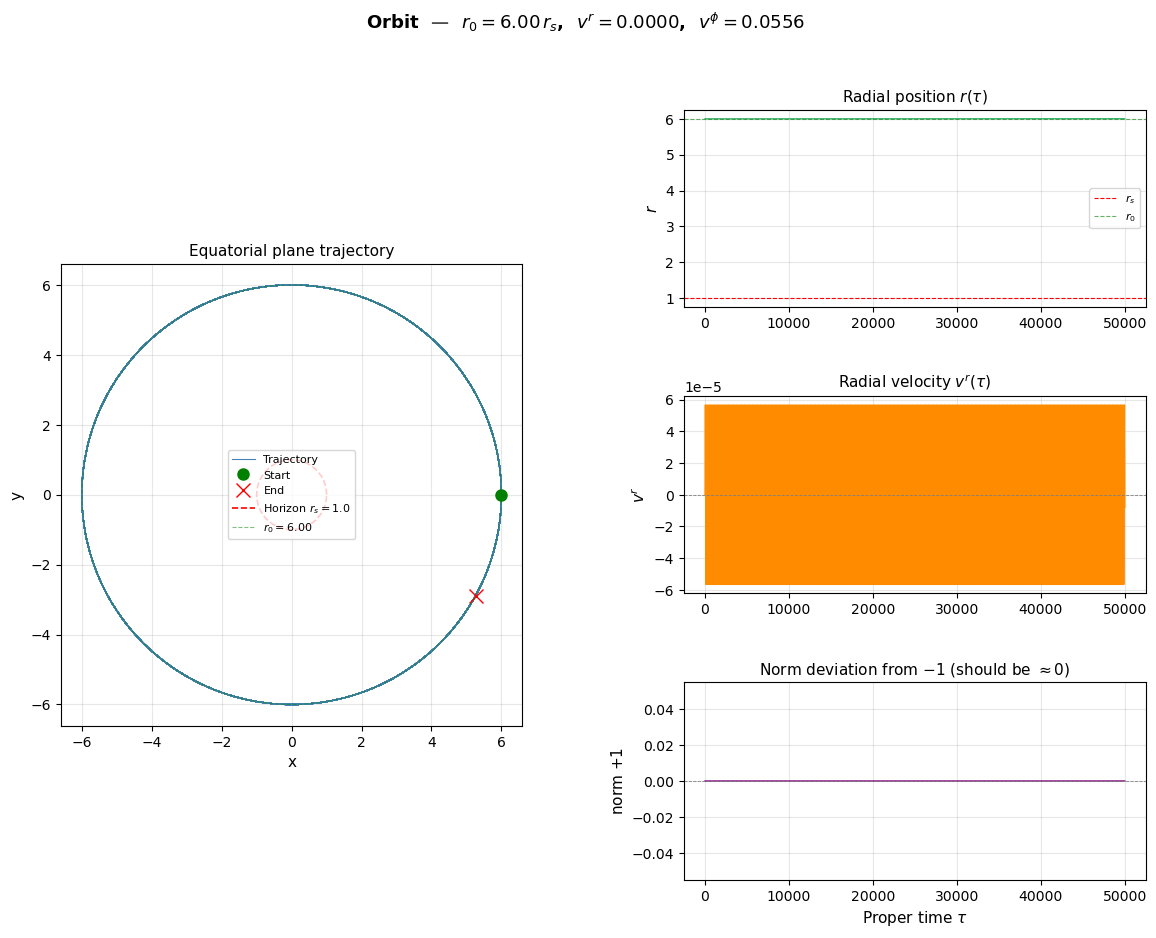

Plot saved to orbital_plot.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ---- Load and clean ----
df = pd.read_csv("orbital.csv")
df = df.dropna()
df = df[np.isfinite(df["r"]) & np.isfinite(df["vr"]) & np.isfinite(df["norm"])]
df = df[df["r"] > 0]
df = df[df["r"] < 1000]

tau  = df["tau"]
r    = df["r"]
phi  = df["phi"]
vr   = df["vr"]
vph  = df["vph"]
norm = df["norm"]

rs = 1.0
r0 = r.iloc[0]

# Cartesian for trajectory
x = r * np.cos(phi)
y = r * np.sin(phi)

# ---- Figure ----
fig = plt.figure(figsize=(14, 10))
fig.suptitle(f"Orbit  —  $r_0={r0:.2f}\\,r_s$,  "
             f"$v^r={vr.iloc[0]:.4f}$,  "
             f"$v^\\phi={vph.iloc[0]:.4f}$",
             fontsize=13, fontweight="bold")

gs = gridspec.GridSpec(3, 2, hspace=0.45, wspace=0.35)

# ---- Panel 1: Trajectory (spans full left column) ----
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(x, y, color="steelblue", linewidth=0.8, label="Trajectory")
ax1.plot(x.iloc[0], y.iloc[0], "go", markersize=8, label="Start")
ax1.plot(x.iloc[-1], y.iloc[-1], "rx", markersize=10, label="End")

theta = np.linspace(0, 2 * np.pi, 300)
ax1.plot(rs * np.cos(theta), rs * np.sin(theta),
         "r--", linewidth=1.2, label=f"Horizon $r_s={rs}$")
ax1.plot(r0 * np.cos(theta), r0 * np.sin(theta),
         "g--", linewidth=0.8, alpha=0.5, label=f"$r_0={r0:.2f}$")

ax1.set_aspect("equal")
ax1.set_xlabel("x", fontsize=11)
ax1.set_ylabel("y", fontsize=11)
ax1.set_title("Equatorial plane trajectory", fontsize=11)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ---- Panel 2: r over tau ----
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(tau, r, color="mediumseagreen", linewidth=1.0)
ax2.axhline(rs, color="red",   linestyle="--", linewidth=0.8, label=r"$r_s$")
ax2.axhline(r0, color="green", linestyle="--", linewidth=0.8, alpha=0.6, label=r"$r_0$")
ax2.set_ylabel(r"$r$", fontsize=11)
ax2.set_title(r"Radial position $r(\tau)$", fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ---- Panel 3: vr over tau ----
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(tau, vr, color="darkorange", linewidth=1.0)
ax3.axhline(0, color="gray", linestyle="--", linewidth=0.6)
ax3.set_ylabel(r"$v^r$", fontsize=11)
ax3.set_title(r"Radial velocity $v^r(\tau)$", fontsize=11)
ax3.grid(True, alpha=0.3)

# ---- Panel 4: norm over tau ----
ax4 = fig.add_subplot(gs[2, 1])
ax4.plot(tau, norm + 1, color="purple", linewidth=1.0)  # plot deviation from -1
ax4.axhline(0, color="gray", linestyle="--", linewidth=0.6)
ax4.set_xlabel(r"Proper time $\tau$", fontsize=11)
ax4.set_ylabel(r"norm $+ 1$", fontsize=11)
ax4.set_title(r"Norm deviation from $-1$ (should be $\approx 0$)", fontsize=11)
ax4.grid(True, alpha=0.3)

plt.savefig("orbital_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to orbital_plot.png")